# Import and setup

In [113]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import librosa
import soundfile as sf

from joblib import Parallel, delayed
from tabulate import tabulate
from sklearn.model_selection import train_test_split
from scipy.signal import welch
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report

In [114]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    print('No GPU detected')

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.44 GB


# Prepare Data for EDA

In [115]:
csv_frdr = r"dataset\urban-frdr\inspections_2022.csv"
csv_zenodo = r"dataset\zenodo\state_labels.csv"
frdr_audiofolder_path = r"dataset/urban-frdr/audio_2022_all_chunk"
zenodo_audiofolder_path = r"dataset\zenodo"

### checking status

In [116]:
df_frdr = pd.read_csv(csv_frdr)
target= df_frdr[(df_frdr['Queen status'] == 'queenless') | (df_frdr['Category'] == 'varroa')]
print(target[['Date', 'Tag number', 'Category', 'Queen status']])

                                 Date  Tag number        Category Queen status
17   2022-08-24 20:30:15.427454+00:00        3627          varroa   queenright
31   2022-07-11 20:23:05.641387+00:00        3692     hive status    queenless
32   2022-07-11 20:23:05.641387+00:00        3692    hive grading    queenless
33   2022-07-11 20:23:05.641387+00:00        3692  frames of bees    queenless
34   2022-07-19 21:32:34.257822+00:00        3692     hive status    queenless
35   2022-07-19 21:32:34.257822+00:00        3692    hive grading    queenless
44   2022-08-24 20:16:33.633384+00:00        3692          varroa   queenright
71   2022-08-24 20:53:05.475343+00:00        3691          varroa   queenright
77   2022-09-30 21:47:53.014515+00:00        3691          varroa   queenright
98   2022-08-24 21:11:39.506501+00:00        3628          varroa   queenright
105  2022-09-30 21:29:31.817886+00:00        3628          varroa   queenright
108  2022-06-02 17:13:07.060900+00:00        3693   

### check status on downloaded chuck

In [130]:
all_files = os.listdir(frdr_audiofolder_path)
extract_list = []
for file_path in all_files:
    if file_path.endswith('.wav'):
        file_name = file_path.split('/')[-1]
        parts = file_name.split('_')
        date = parts[0]
        hive_part = parts[2]
        hive_id = hive_part.split('-')[1].split('.')[0]
        for_merge = pd.to_datetime(date, format='%d-%m-%Y').strftime('%Y-%m-%d')
        extract_list.append({
            'Filename': file_name,
            'Date': for_merge,
            'Tag number': int(hive_id)
        })

df_audio = pd.DataFrame(extract_list)
df_audio['Tag number'] = df_audio['Tag number'].astype(int)

df_frdr['Tag number'] = df_frdr['Tag number'].astype(int)
df_frdr['Date'] = pd.to_datetime(df_frdr['Date']).dt.strftime('%Y-%m-%d')

df_frdr_sorted = df_frdr.sort_values(by=['Date', 'Tag number', 'Category'], ascending=[True, True, False])
df_frdr_clean = df_frdr_sorted.drop_duplicates(subset=['Date', 'Tag number'], keep='first')
merge_df = pd.merge(df_audio, df_frdr_clean, on=['Date', 'Tag number'], how='inner')

def check_class(row):
    if row['Category'] == 'varroa':
        return 'Class 2: Infested'
    elif row['Queen status'] == 'queenless':
        return 'Class 1: Queenless'
    elif row['Queen status'] == 'queenright' and row['Is alive'] == 1:
        return 'Class 0: Active'
    else:
        return 'Others / Ignored'
merge_df['target_Class'] = merge_df.apply(check_class, axis=1)

# Check Other / Ignored (deaded bee)
# print(merge_df[merge_df['target_Class'] == 'Others / Ignored'])

# for index, row in merge_df.iterrows():
#     print(f"{index}. File: {row['Filename']} | {row['target_Class']}")
print(merge_df['target_Class'].value_counts())

target_Class
Class 2: Infested     162
Class 0: Active       147
Class 1: Queenless     83
Name: count, dtype: int64


# Exploratory Data Analysis (EDA)

### Compare noise level (Active)

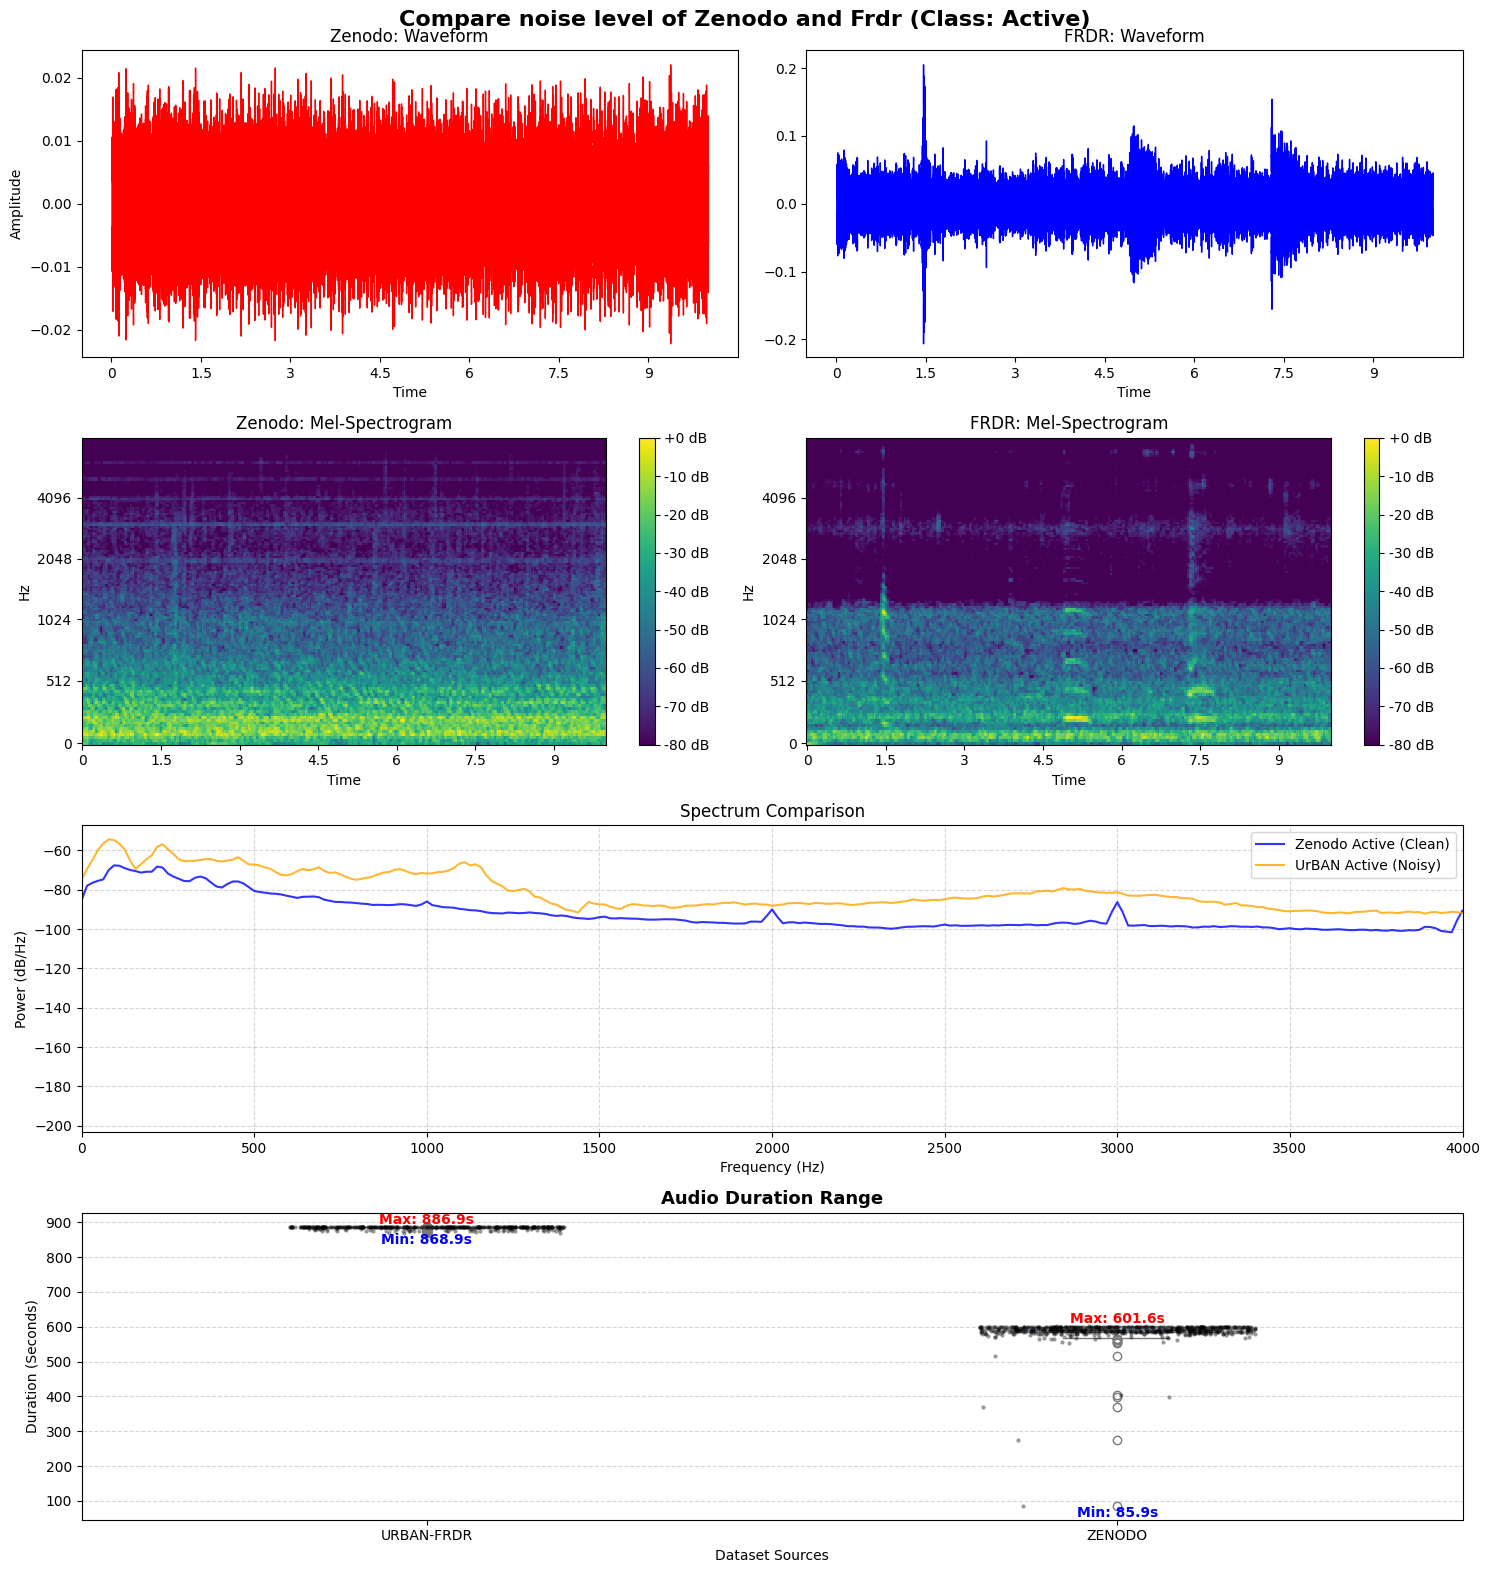

In [131]:
zenodo_active_path = r"dataset\zenodo\Hive1_12_06_2018\Hive1 12_06_2018_QueenBee____00_00_00.wav"
frdr_active_path = r"dataset\urban-frdr\audio_2022_all_chunk\01-09-2022_20h30_HIVE-3693_Active.wav"

sr = 16000
audio_zenodo, sr_z = librosa.load(zenodo_active_path, sr=sr)
audio_frdr, sr_f = librosa.load(frdr_active_path, sr=sr)

duration = 10 #(Sec)
audio_zenodo = audio_zenodo[:sr * duration]
audio_frdr = audio_frdr[:sr * duration]
# print(audio_frdr)

all_audio_files = glob.glob(r"dataset\**\*.wav", recursive=True)

all_duration_data = []

for path in all_audio_files:
    filename = os.path.basename(path)
    dataset_name = None
    
    filename_lower = filename.lower()
    if any(s in filename_lower for s in ["_active", "_queenless", "_infested"]):
        dataset_name = 'URBAN-FRDR'
    elif any(s in filename_lower for s in ["queenbee", "no_queenbee"]):
        dataset_name = 'ZENODO'
        
    if dataset_name:
        try:
            file_duration = librosa.get_duration(path=path)
            
            all_duration_data.append({
                'Dataset': dataset_name,
                'Duration': file_duration
            })
        except Exception as e:
            print(f"Error reading {filename}: {e}")

df_durations = pd.DataFrame(all_duration_data)

fig, axs = plt.subplots(4, 2, figsize=(15, 16), sharex=False)
fig.suptitle("Compare noise level of Zenodo and Frdr (Class: Active)", fontsize=16, fontweight='bold')
axs[0, 0].set_title("Zenodo: Waveform")
librosa.display.waveshow(audio_zenodo, sr=sr, ax=axs[0, 0], color='red')
axs[0, 0].set_ylabel("Amplitude")

axs[0, 1].set_title("FRDR: Waveform")
librosa.display.waveshow(audio_frdr, sr=sr, ax=axs[0, 1], color='blue')

#=============================================================

mel_zenodo = librosa.feature.melspectrogram(y=audio_zenodo, sr=sr, n_mels=128)
mel_db_zenodo = librosa.amplitude_to_db(mel_zenodo, ref=np.max)

axs[1, 0].set_title("Zenodo: Mel-Spectrogram")
img1 = librosa.display.specshow(mel_db_zenodo, sr=sr, x_axis='time', y_axis='mel', ax=axs[1, 0], cmap='viridis')
fig.colorbar(img1, ax=axs[1,0], format='%+2.0f dB')

mel_frdr = librosa.feature.melspectrogram(y=audio_frdr, sr=sr, n_mels=128)
mel_db_frdr = librosa.amplitude_to_db(mel_frdr, ref=np.max)
axs[1, 1].set_title("FRDR: Mel-Spectrogram")
img2 = librosa.display.specshow(mel_db_frdr, sr=sr, x_axis='time', y_axis='mel', ax=axs[1, 1], cmap='viridis')
fig.colorbar(img2, ax=axs[1,1], format='%+2.0f dB')

#=============================================================

freqs_z, psd_z = welch(audio_zenodo, sr, nperseg=1024)
freqs_u, psd_u = welch(audio_frdr, sr, nperseg=1024)

axs[2, 0].remove()
axs[2, 1].remove()
ax_psd = fig.add_subplot(4, 1, 3)

ax_psd.plot(freqs_z, 10 * np.log10(psd_z), label='Zenodo Active (Clean)', color='blue', alpha=0.8)
ax_psd.plot(freqs_u, 10 * np.log10(psd_u), label='UrBAN Active (Noisy)', color='orange', alpha=0.8)
ax_psd.set_title("Spectrum Comparison")
ax_psd.set_xlabel("Frequency (Hz)")
ax_psd.set_ylabel("Power (dB/Hz)")
ax_psd.set_xlim(0, 4000)
ax_psd.grid(True, linestyle='--', alpha=0.5)
ax_psd.legend()

#=============================================================

axs[3, 0].remove()
axs[3, 1].remove()
ax_duration = fig.add_subplot(4, 1, 4)

if len(df_durations) > 0:
    sns.boxplot(data=df_durations, x='Dataset', y='Duration', ax=ax_duration, palette='Pastel1', width=0.3, hue='Dataset', legend=False,)
    sns.stripplot(data=df_durations, x='Dataset', y='Duration', ax=ax_duration, color='black', size=3, alpha=0.4, jitter=0.2)
    
    for i, dataset_name in enumerate(['URBAN-FRDR', 'ZENODO']):
        sub_df = df_durations[df_durations['Dataset'] == dataset_name]['Duration']
        if len(sub_df) > 0:
            ax_duration.text(i, sub_df.max(), f"Max: {sub_df.max():.1f}s", ha='center', va='bottom', color='red', fontweight='bold', fontsize=10)
            ax_duration.text(i, sub_df.min(), f"Min: {sub_df.min():.1f}s", ha='center', va='top', color='blue', fontweight='bold', fontsize=10)

ax_duration.set_title("Audio Duration Range", fontsize=13, fontweight='bold')
ax_duration.set_xlabel("Dataset Sources")
ax_duration.set_ylabel("Duration (Seconds)")
ax_duration.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [119]:
too_short = df_durations[
    (df_durations['Dataset'] == 'ZENODO') &
    (df_durations['Duration'] < 500)
]

if len(too_short) > 0:
    print(f"Too short found: {len(too_short)} File\n")
    for idx, row in too_short.iterrows():
        target_duration = row['Duration']
        for path in all_audio_files:
            if "queenbee" in path.lower() or "no_queenbee" in path.lower():
                try:
                    d = librosa.get_duration(path=path)
                    if abs(d - target_duration) < 0.1:
                        found_filename = os.path.basename(path)
                        break
                except:
                    pass
        
        print(f"File name: {found_filename}")
        print(f"Duration: {target_duration:.2f} Sec (About {target_duration/60:.1f} Min)")
else:
    print("Not found")

Too short found: 5 File

File name: Hive3_14_07_2017_NO_QueenBee____07_30_00.wav
Duration: 274.00 Sec (About 4.6 Min)
File name: Hive3_14_07_2017_NO_QueenBee____09_30_00.wav
Duration: 397.06 Sec (About 6.6 Min)
File name: Hive3_28_07_2017_QueenBee____07_40_00.wav
Duration: 369.20 Sec (About 6.2 Min)
File name: Hive3_28_07_2017_QueenBee____11_30_00.wav
Duration: 402.52 Sec (About 6.7 Min)
File name: Hive3_28_07_2017_QueenBee____12_40_00.wav
Duration: 85.91 Sec (About 1.4 Min)


In [132]:
frdr_hives = df_audio['Tag number'].unique()
total_frdr_hives = len(frdr_hives)

print(f"Total FRDR Hive: {total_frdr_hives} hives")
print(f"FRDR Name list: {sorted(frdr_hives)}")
counts = df_audio['Tag number'].value_counts().sort_index()
print(f"Total FRDR Hive: {total_frdr_hives} hives")
print("Files per hive:")
for hive, cnt in counts.items():
        print(f"  Hive {hive}: {cnt} files")

Total FRDR Hive: 9 hives
FRDR Name list: [np.int64(6), np.int64(3627), np.int64(3628), np.int64(3631), np.int64(3640), np.int64(3690), np.int64(3691), np.int64(3692), np.int64(3693)]
Total FRDR Hive: 9 hives
Files per hive:
  Hive 6: 100 files
  Hive 3627: 5 files
  Hive 3628: 31 files
  Hive 3631: 65 files
  Hive 3640: 41 files
  Hive 3690: 65 files
  Hive 3691: 15 files
  Hive 3692: 4 files
  Hive 3693: 67 files


# Data split

In [121]:
def split_data(df, stratify_col):

    if stratify_col in df.columns:
        stratify_vals = df[stratify_col]
    else:
        stratify_vals = None

    if stratify_vals is not None:
        counts = stratify_vals.value_counts()
        if counts.min() < 2:
            stratify_vals = None
    
    if len(df) < 10:
        if stratify_vals is not None:
            train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=stratify_vals)
        else:
            train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)
        
        if stratify_vals is not None and stratify_col in temp_df.columns and temp_df[stratify_col].nunique() > 1:
            val_df, test_df = train_test_split(
                temp_df,
                test_size=0.50,
                random_state=42,
                stratify=temp_df[stratify_col]
            )
        else:
            val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)
        return train_df, val_df, test_df
    
    if stratify_vals is not None:
        train_df, temp_df = train_test_split(
            df,
            test_size=0.20,
            random_state=42,
            stratify=stratify_vals
        )
    else:
        train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)

    if stratify_vals is not None and stratify_col in temp_df.columns:
        counts_temp = temp_df[stratify_col].value_counts()
        if counts_temp.min() < 2:
            val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)
        else:
            val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df[stratify_col])
    else:
        val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

    return train_df, val_df, test_df

In [122]:
frdr_files = glob.glob(os.path.join(frdr_audiofolder_path, "*.wav"))
frdr_data = []

for path in frdr_files:
    filename = os.path.basename(path)
    if any(suffix in filename for suffix in ["_Active", "_Queenless", "_Infested"]):
        name_part, _ = os.path.splitext(filename)
        parts = name_part.split('_')
        class_label = parts[-1]

        hive_id = "Unknown"
        for p in parts:
            if "HIVE" in p:
                hive_id = p
                break

        frdr_data.append({
            'File_Path': path,
            'Filename': filename,
            'Dataset': 'FRDR',
            'Class': class_label,
            'Hive': hive_id
        })

df_frdr_all = pd.DataFrame(frdr_data)

# ----------------------------------------------------- zenodo
zenodo_files = glob.glob(os.path.join(zenodo_audiofolder_path, "*", "*.wav"))
zenodo_data = []

for path in zenodo_files:
    filename = os.path.basename(path)
    folder_name = os.path.basename(os.path.dirname(path))
    
    if "NO_QueenBee" in filename:
        class_label = "Queenless"
    elif "QueenBee" in filename:
        class_label = "Active"
    else:
        continue
        
    hive_id = folder_name.split('_')[0]
    
    zenodo_data.append({
        'File_Path': path,
        'Filename': filename,
        'Dataset': 'ZENODO',
        'Class': class_label,
        'Hive': hive_id
    })

df_zenodo_all = pd.DataFrame(zenodo_data)

print(f"UrBAN-FRDR: {len(df_frdr_all)} Files")
print(f"Zenodo: {len(df_zenodo_all)} Files")

zenodo_train_list, zenodo_val_list, zenodo_test_list = [], [], []

for folder, group in df_zenodo_all.groupby('Dataset'):
    z_train, z_val, z_test = split_data(group, stratify_col='Class')
    zenodo_train_list.append(z_train)
    zenodo_val_list.append(z_val)
    zenodo_test_list.append(z_test)

train_zenodo = pd.concat(zenodo_train_list) if len(zenodo_train_list) > 0 else pd.DataFrame()
val_zenodo = pd.concat(zenodo_val_list) if len(zenodo_val_list) > 0 else pd.DataFrame()
test_zenodo = pd.concat(zenodo_test_list) if len(zenodo_test_list) > 0 else pd.DataFrame()

df_frdr_all['Stratify_Key'] = df_frdr_all['Class'] + "_" + df_frdr_all['Hive']

counts = df_frdr_all['Stratify_Key'].value_counts()
rare_keys = counts[counts < 10].index
df_frdr_all['Stratify_Key'] = df_frdr_all['Stratify_Key'].apply(lambda x: x.split('_')[0] if x in rare_keys else x)

train_frdr, val_frdr, test_frdr = split_data(df_frdr_all, stratify_col='Stratify_Key')

train_df = pd.concat([train_zenodo, train_frdr], ignore_index=True)
val_df = pd.concat([val_zenodo, val_frdr], ignore_index=True)
test_df = pd.concat([test_zenodo, test_frdr], ignore_index=True)

for df in [train_df, val_df, test_df]:
    df.drop(columns=['Stratify_Key'], errors='ignore', inplace=True)

print(f"Total files: Train = {len(train_df)} | Val = {len(val_df)} | Test = {len(test_df)}")
print("\n")

print("1. Split by Dataset:")
summary_dataset = pd.DataFrame({
    'Train_Set': train_df['Dataset'].value_counts(),
    'Val_Set': val_df['Dataset'].value_counts(),
    'Test_Set': test_df['Dataset'].value_counts()
}).fillna(0).astype(int)
summary_dataset['Total'] = summary_dataset.sum(axis=1)
print(summary_dataset)
print("\n")

print("2. Split by Class:")
summary_class = pd.DataFrame({
    'Train_Set': train_df['Class'].value_counts(),
    'Val_Set': val_df['Class'].value_counts(),
    'Test_Set': test_df['Class'].value_counts()
}).fillna(0).astype(int)
summary_class['Total'] = summary_class.sum(axis=1)
print(summary_class)
print("\n")

print("3. Split by Hive:")
summary_hive = pd.DataFrame({
    'Train_Set': train_df['Hive'].value_counts(),
    'Val_Set': val_df['Hive'].value_counts(),
    'Test_Set': test_df['Hive'].value_counts()
}).fillna(0).astype(int)
summary_hive['Total'] = summary_hive.sum(axis=1)
print(summary_hive)

UrBAN-FRDR: 372 Files
Zenodo: 576 Files
Total files: Train = 757 | Val = 95 | Test = 96


1. Split by Dataset:
         Train_Set  Val_Set  Test_Set  Total
Dataset                                     
ZENODO         460       58        58    576
FRDR           297       37        38    372


2. Split by Class:
           Train_Set  Val_Set  Test_Set  Total
Class                                         
Active           344       46        42    432
Queenless        291       37        36    364
Infested         122       12        18    152


3. Split by Hive:
           Train_Set  Val_Set  Test_Set  Total
Hive                                          
HIVE-3627          2        1         0      3
HIVE-3628         25        4         2     31
HIVE-3631         50        6         7     63
HIVE-3640         31        3         5     39
HIVE-3690         48        6         6     60
HIVE-3691         12        2         1     15
HIVE-3692          3        0         0      3
HIVE-3693 

## Slice Audio Data --> 30s

In [123]:
sr = 16000

def make_mel_tensor(audio_chunk, sr=sr, target_size=(224, 224)):
    mel_spec = librosa.feature.melspectrogram(
        y=audio_chunk, sr=sr, n_fft=1024, hop_length=512, n_mels=128
    )
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_tensor = torch.from_numpy(mel_db).float().unsqueeze(0).unsqueeze(0)
    mel_resized = torch.nn.functional.interpolate(
        mel_tensor, size=target_size, mode='bilinear', align_corners=False
    ).squeeze(0)

    mel_rgb = mel_resized.repeat(3, 1, 1)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (mel_rgb - mean) / std

def audio_chunks(df, is_train=True, chunk_length_s=30, max_eval_chunks=2, target_size=(224, 224)):
    chunked_data = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing chunks"):
        file_path = row['File_Path']
        label = row['Class']

        try:
            duration_s = librosa.get_duration(path=file_path)
            total_chunks = int(duration_s // chunk_length_s)

            if total_chunks == 0:
                print(f"{file_path} too short for 30s chunks")
                continue

            if is_train:
                indices_to_use = range(total_chunks)
            else:
                indices_to_use = np.random.choice(range(total_chunks), min(total_chunks, max_eval_chunks), replace=False)

            for i in indices_to_use:
                offset_s = i * chunk_length_s
                y, _ = librosa.load(file_path, sr=sr, mono=True, offset=offset_s, duration=chunk_length_s)

                if len(y) < chunk_length_s * sr:
                    print(f"  Warning: chunk {i} in {file_path} shorter than {chunk_length_s}s, skipping")
                    continue

                melspec_tensor = make_mel_tensor(y, sr=sr, target_size=target_size)
                chunked_data.append({
                    'File_Path': file_path,
                    'Class': label,
                    'chunk_id': i,
                    'mel_tensor': melspec_tensor
                })
        except Exception as e:
            print(f"  Error loading {file_path}: {e}")
            continue

    return pd.DataFrame(chunked_data)

train_chunks_df = audio_chunks(train_df, is_train=True, chunk_length_s=30, target_size=(224, 224))
print(f'Train chunks: {len(train_chunks_df)} chunks {len(train_df)} files')
print('Processing validation audio chunks')
val_chunks_df = audio_chunks(val_df, is_train=False, chunk_length_s=30, max_eval_chunks=2, target_size=(224, 224))
print(f'Val chunks: {len(val_chunks_df)} chunks {len(val_df)} files')
print('Processing test audio chunks')
test_chunks_df = audio_chunks(test_df, is_train=False, chunk_length_s=30, max_eval_chunks=2, target_size=(224, 224))
print(f'Test chunks: {len(test_chunks_df)} chunks {len(test_df)} files')
print(f'\nLabel distribution in chunks')
print(f'Train: {train_chunks_df["Class"].value_counts().to_dict()}')
print(f'Val: {val_chunks_df["Class"].value_counts().to_dict()}')
print(f'Test: {test_chunks_df["Class"].value_counts().to_dict()}')

Processing chunks: 100%|██████████| 757/757 [16:50<00:00,  1.33s/it]


Train chunks: 17297 chunks 757 files
Processing validation audio chunks


Processing chunks: 100%|██████████| 95/95 [00:09<00:00,  9.62it/s]


Val chunks: 190 chunks 95 files
Processing test audio chunks


Processing chunks: 100%|██████████| 96/96 [00:09<00:00,  9.76it/s]

Test chunks: 192 chunks 96 files

Label distribution in chunks
Train: {'Active': 7638, 'Queenless': 6121, 'Infested': 3538}
Val: {'Active': 92, 'Queenless': 74, 'Infested': 24}
Test: {'Active': 84, 'Queenless': 72, 'Infested': 36}


In [ ]:
def downsample(df, infested_label='Infested', other_labels=('Active', 'Queenless')):
    label_counts = df['label'].value_counts()
    target_count = int(label_counts.get(infested_label, 0))
    if target_count == 0:
        return df

    balanced = []
    for label, group in df.groupby('label'):
        if label in other_labels:
            if len(group) > target_count:
                balanced.append(group.sample(n=target_count, random_state=42))
            else:
                balanced.append(group)
        else:
            balanced.append(group)

    balanced_df = pd.concat(balanced, ignore_index=True)
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
    return balanced_df

balanced_train_chunks_df = downsample(train_chunks_df)
balanced_val_chunks_df = downsample(val_chunks_df)
print(balanced_train_chunks_df['label'].value_counts().to_dict())
print(balanced_val_chunks_df['label'].value_counts().to_dict())

# Model Training

## model Models

In [124]:
import timm
models = timm.list_models('*modelv4*')
print(models)

[]


In [125]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import timm

from IPython.display import clear_output

class ChunkDataset(Dataset):
    def __init__(self, chunks_df):
        self.chunks_df = chunks_df.reset_index(drop=True)
        self.label_map = {'Active': 0, 'Queenless': 1, 'Infested': 2}

    def __len__(self):
        return len(self.chunks_df)

    def __getitem__(self, idx):
        row = self.chunks_df.iloc[idx]
        mel_tensor = row['mel_tensor']
        if not isinstance(mel_tensor, torch.Tensor):
            mel_tensor = torch.tensor(mel_tensor, dtype=torch.float32)

        label_str = row['Class']
        label_encoded = self.label_map.get(label_str, 0)
        return mel_tensor, torch.tensor(label_encoded, dtype=torch.long)

train_dataset = ChunkDataset(train_chunks_df)
val_dataset = ChunkDataset(val_chunks_df)
test_dataset = ChunkDataset(test_chunks_df)

pin_memory = True if torch.cuda.is_available() else False
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)

# mobilenet = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
# mobilenet = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
mobilenet = timm.create_model('mobilenetv4_hybrid_large', pretrained=True, num_classes=3)

print(mobilenet.classifier)

mobilenet = mobilenet.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(mobilenet.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

NUM_EPOCHS = 15
best_val_loss = float('inf')
results_table = []
headers = ["Epoch", "Train Loss", "Train Acc", "Val Loss", "Val Acc"]

for epoch in range(NUM_EPOCHS):

    mobilenet.train()
    running_loss, correct, total = 0.0, 0, 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    
    for images, labels in train_loop:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = mobilenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        train_loop.set_postfix(loss=f"{loss.item():.4f}")
        
    train_loss, train_acc = running_loss / total, correct / total
    
    mobilenet.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = mobilenet(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_loss, val_acc = val_loss / val_total, val_correct / val_total
    scheduler.step()
    
    results_table.append([epoch+1, f"{train_loss:.4f}", f"{train_acc:.4f}", f"{val_loss:.4f}", f"{val_acc:.4f}"])

    clear_output(wait=True)
    print(tabulate(results_table, headers=headers, tablefmt="simple_outline"))
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(mobilenet.state_dict(), 'best_mobilenet_bee_model.pth')
        print(f"    Saved best model at epoch {epoch+1}")

┌─────────┬──────────────┬─────────────┬────────────┬───────────┐
│   Epoch │   Train Loss │   Train Acc │   Val Loss │   Val Acc │
├─────────┼──────────────┼─────────────┼────────────┼───────────┤
│       1 │       0.928  │      0.8111 │     0.233  │    0.8895 │
│       2 │       0.1317 │      0.9507 │     0.105  │    0.9579 │
│       3 │       0.0645 │      0.9784 │     0.1313 │    0.9632 │
│       4 │       0.0296 │      0.9891 │     0.1544 │    0.9368 │
│       5 │       0.0317 │      0.9898 │     0.1813 │    0.9368 │
│       6 │       0.018  │      0.9944 │     0.166  │    0.9474 │
│       7 │       0.0109 │      0.9964 │     0.1011 │    0.9579 │
│       8 │       0.0035 │      0.9987 │     0.1051 │    0.9632 │
│       9 │       0.0022 │      0.9992 │     0.159  │    0.9579 │
│      10 │       0.0014 │      0.9995 │     0.1474 │    0.9579 │
│      11 │       0.0009 │      0.9997 │     0.1283 │    0.9684 │
│      12 │       0.0015 │      0.9996 │     0.1494 │    0.9684 │
│      13 

## ResNet Models

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import timm
from IPython.display import clear_output

class ChunkDataset(Dataset):
    def __init__(self, chunks_df):
        self.chunks_df = chunks_df.reset_index(drop=True)
        self.label_map = {'Active': 0, 'Queenless': 1, 'Infested': 2}

    def __len__(self):
        return len(self.chunks_df)

    def __getitem__(self, idx):
        row = self.chunks_df.iloc[idx]
        mel_tensor = row['mel_tensor']
        if not isinstance(mel_tensor, torch.Tensor):
            mel_tensor = torch.tensor(mel_tensor, dtype=torch.float32)

        label_str = row['Class']
        label_encoded = self.label_map.get(label_str, 0)
        return mel_tensor, torch.tensor(label_encoded, dtype=torch.long)

train_dataset = ChunkDataset(train_chunks_df)
val_dataset = ChunkDataset(val_chunks_df)
test_dataset = ChunkDataset(test_chunks_df)

pin_memory = True if torch.cuda.is_available() else False
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)

model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

NUM_EPOCHS = 15
best_val_loss = float('inf')
results_table = []
headers = ["Epoch", "Train Loss", "Train Acc", "Val Loss", "Val Acc"]

for epoch in range(NUM_EPOCHS):

    model.train()
    running_loss, correct, total = 0.0, 0, 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    
    for images, labels in train_loop:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        train_loop.set_postfix(loss=f"{loss.item():.4f}")
        
    train_loss, train_acc = running_loss / total, correct / total
    
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_loss, val_acc = val_loss / val_total, val_correct / val_total
    scheduler.step()
    
    results_table.append([epoch+1, f"{train_loss:.4f}", f"{train_acc:.4f}", f"{val_loss:.4f}", f"{val_acc:.4f}"])

    clear_output(wait=True)
    print(tabulate(results_table, headers=headers, tablefmt="simple_outline"))
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_mobilenet_bee_model.pth')
        print(f"    Saved best model at epoch {epoch+1}")

Epoch 1/15:   1%|          | 3/541 [00:20<1:00:55,  6.79s/it, loss=1.0908]

============== Classification Report ===============
              precision    recall  f1-score   support

      Active       0.96      0.98      0.97        92
   Queenless       1.00      1.00      1.00        74
    Infested       0.91      0.83      0.87        24

    accuracy                           0.97       190
   macro avg       0.96      0.94      0.95       190
weighted avg       0.97      0.97      0.97       190



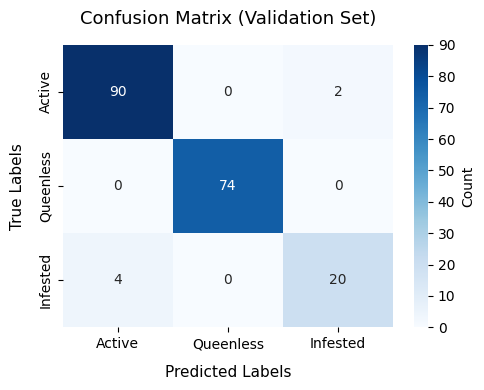

In [127]:
def plot_metrics(model, dataloader, device, class_names, split_name=None):
    model.eval()
    all_preds = []
    all_labels = []
    
    desc = f"Processing ({split_name})" if split_name else "Processing"
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("============== Classification Report ===============")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar_kws={'label': 'Count'})

    ax.set_xlabel('Predicted Labels', fontsize=11, labelpad=10)
    ax.set_ylabel('True Labels', fontsize=11, labelpad=10)
    title = 'Confusion Matrix'
    if split_name:
        title += f" ({split_name})"
    ax.set_title(title, fontsize=13, pad=15)
    plt.tight_layout()
    plt.show()

    return all_preds, all_labels

class_labels = ['Active', 'Queenless', 'Infested']
val_preds, val_labels = plot_metrics(mobilenet, val_loader, DEVICE, class_labels, split_name="Validation Set")
